In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../../../data_capsule/ROUND_2/prices_round_2_day_-1.csv", sep=";")

# print(df.columns)
# print(df.head())


osmium = df[df["product"] == "ASH_COATED_OSMIUM"].copy()
osmium = osmium.sort_values("timestamp")

osmium = osmium[
    (osmium["bid_price_1"] > 0) &
    (osmium["ask_price_1"] > 0)
]
osmium["mid"] = (osmium["bid_price_1"] + osmium["ask_price_1"]) / 2

osmium_sampled = osmium.iloc[::20]


In [21]:
# ===== EMA =====
class EMAFilter:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.value = None

    def update(self, price):
        if self.value is None:
            self.value = price
        else:
            self.value = self.alpha * price + (1 - self.alpha) * self.value
        return self.value


# ===== DOUBLE EMA =====
class DoubleEMA:
    def __init__(self, alpha=0.2):
        self.ema1 = EMAFilter(alpha)
        self.ema2 = EMAFilter(alpha)

    def update(self, price):
        e1 = self.ema1.update(price)
        e2 = self.ema2.update(e1)
        return 2 * e1 - e2

In [22]:
# ===== APPLY FILTER =====
ema = EMAFilter(alpha=0.2)

filtered = []
for p in osmium_sampled["mid"]:
    filtered.append(ema.update(p))

osmium_sampled["filtered"] = filtered

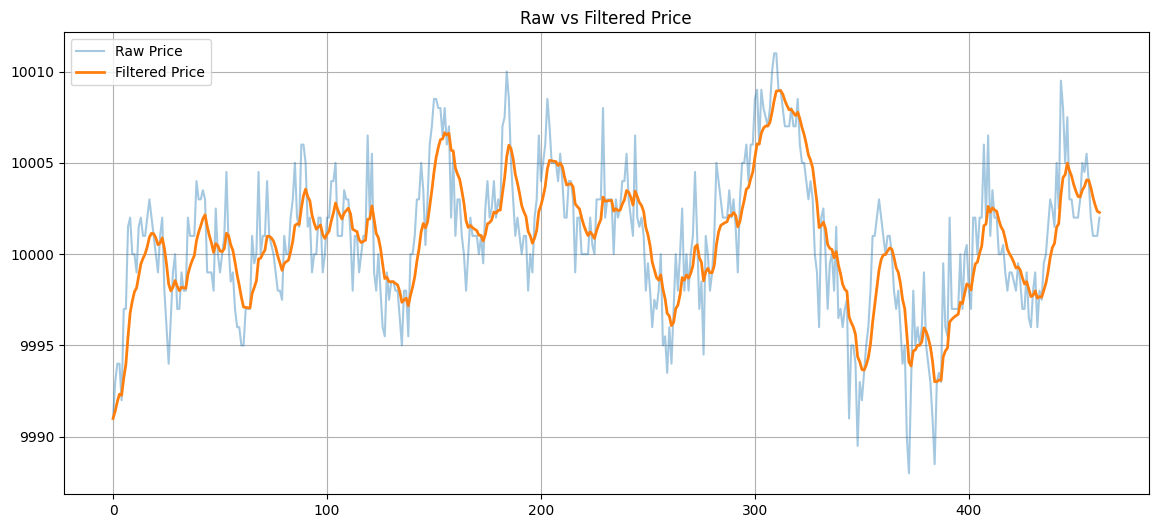

In [23]:
# ===== PLOT RAW vs FILTERED =====
plt.figure(figsize=(14,6))

plt.plot(osmium_sampled["mid"].values, label="Raw Price", alpha=0.4)
plt.plot(osmium_sampled["filtered"].values, label="Filtered Price", linewidth=2)

plt.title("Raw vs Filtered Price")
plt.legend()
plt.grid()

plt.show()

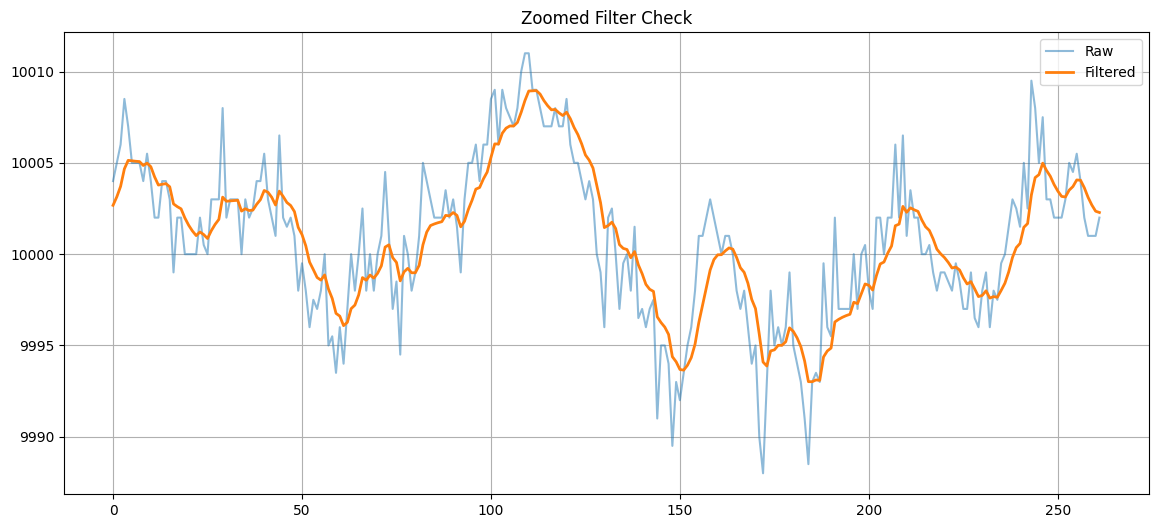

In [24]:
# ===== ZOOMED VIEW =====
start = 200
end = 600

plt.figure(figsize=(14,6))

plt.plot(osmium_sampled["mid"].iloc[start:end].values, label="Raw", alpha=0.5)
plt.plot(osmium_sampled["filtered"].iloc[start:end].values, label="Filtered", linewidth=2)

plt.title("Zoomed Filter Check")
plt.legend()
plt.grid()

plt.show()

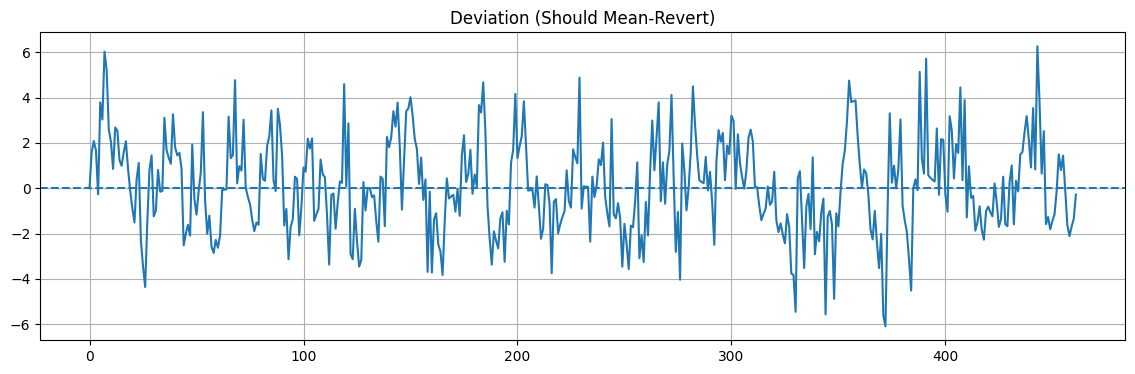

In [25]:
# ===== DEVIATION =====
osmium_sampled["deviation"] = osmium_sampled["mid"] - osmium_sampled["filtered"]

plt.figure(figsize=(14,4))
plt.plot(osmium_sampled["deviation"].values)
plt.axhline(0, linestyle="--")

plt.title("Deviation (Should Mean-Revert)")
plt.grid()
plt.show()

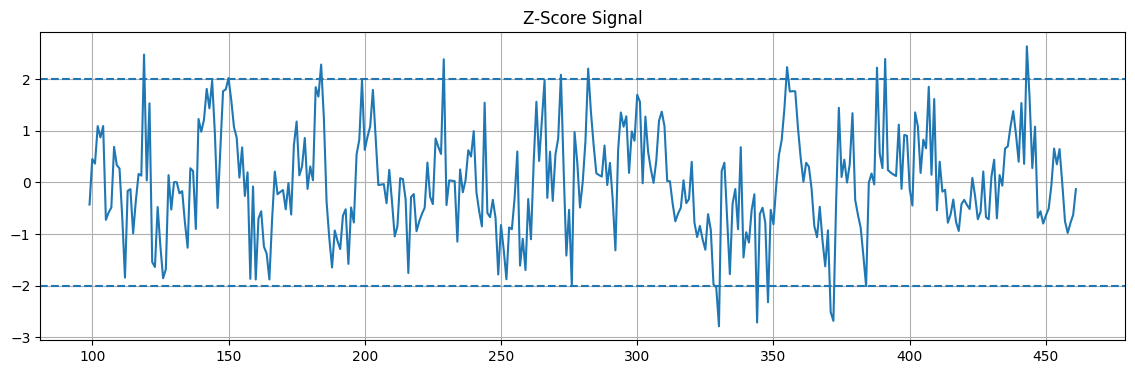

In [26]:
# ===== Z-SCORE =====
rolling_std = osmium_sampled["deviation"].rolling(100).std()

osmium_sampled["zscore"] = osmium_sampled["deviation"] / rolling_std

plt.figure(figsize=(14,4))
plt.plot(osmium_sampled["zscore"].values)
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.title("Z-Score Signal")
plt.grid()
plt.show()

In [27]:
# ===== PREDICTIVE CHECK =====
import numpy as np

price = osmium_sampled["mid"].values
z = osmium_sampled["zscore"].values

future_return = np.roll(price, -1) - price

mask = ~np.isnan(z)

corr = np.corrcoef(z[mask][:-1], future_return[mask][:-1])[0,1]
print("Z-score vs Future Return Correlation:", corr)

Z-score vs Future Return Correlation: -0.2940012132152461


In [28]:
# corr, df = evaluate_alpha(0.2)

osmium_sampled = df  # overwrite